    # 1. The reconciliation, skipped

    **Week 1, Friday. The lab debrief, chapter 1 of 3: do the quarters in your note match the books?**

    Anand Iyer, finance controller, said it on Wednesday and it still holds: "Until your numbers match
    ours, Finance will not act on a drop measured from an ERP export."

    **The metric at stake.** Booked revenue per quarter, and the change from Q1 to Q2 that the note to
    Meera Raghavan leads with. **Who asks.** Anand, before he lets any number reach Meera's growth
    review, and Meera, who acts on the first line of the note. **What a wrong number costs.** A note
    that calls a falling quarter a rising one sends Monday's review home with no investigation, and
    Marketing's Rs 12 crore acquisition request gets judged against a quarter that did not happen.
    Anand returns the note, and the team's next number is read with suspicion.

    **Who else faces this.** Nykaa, the beauty and fashion retailer, reports two numbers for the same quarter:
    for April to June 2025, consolidated GMV of Rs 4,182 crore and revenue from operations of Rs 2,155
    crore (FSN E-Commerce Ventures press release, 12 August 2025). An analyst there who quotes one to
    the owner of the other is out by nearly half, so every internal figure says which it is and bridges
    to the books. A public case shows what an unreconciled pipeline hides: in October 2020 Public Health
    England said 15,841 positive COVID-19 cases from 25 September to 2 October had been left out of the
    reported daily figures because files exceeded a size limit (UK government statement, 4 October 2020).
    No step raised an error; the rows were simply not there.

    **Where this starts.** This morning each of you ran the week's method alone on the lab export. This
    notebook replays the step most rooms dropped when the clock ran, the reconciliation, and shows what
    the note said without it. Chapter 2 picks up the case where a count check passes and the rupees do
    not; chapter 3 takes the clean numbers into the tree.

**Before you read on.** This notebook runs on this morning's lab export and shows the morning's
numbers. It opens after the lab clock stops, and it is the debrief's text for self-study too.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import statistics
import time

rows = kit.load_csv("C2_W01_D05_lab_orders_STUDENT.csv")
control = {c["quarter"]: c for c in kit.load_csv("C2_W01_D05_lab_control_STUDENT.csv")}
QUARTERS = ("Q1", "Q2")


def change(a, b):
    """Percentage change from a to b."""
    return 100 * (b / a - 1)


def ctl(q):
    return int(control[q]["amount_rs"]), int(control[q]["orders"])


print(f"{len(rows)} rows read from the lab export; Finance's control totals for {', '.join(sorted(control))}")

207 rows read from the lab export; Finance's control totals for Q1, Q2


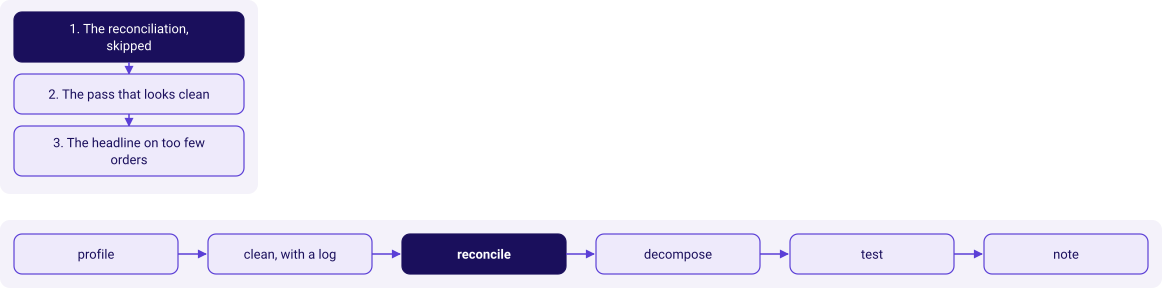

In [2]:
kit.side_by_side(
    kit.ladder(["The reconciliation, skipped", "The pass that looks clean", "The headline on too few orders"],
               lit=0, show=False),
    kit.flow(["profile", "clean, with a log", "reconcile", "decompose", "test", "note"], lit=2, show=False),
)

## The options

The question at this step is narrow: before a single branch of the tree is read, is the data you
cleaned still the data Finance booked? A team has four ways to answer it.

| Option | What it does | What it needs |
|---|---|---|
| A. Trust the pass | Sum what the cleaning pass kept and move on to the tree | Nothing |
| B. Count check | Rows read equal rows kept plus rows rejected, and orders per quarter equal Finance's order counts | The control file's order counts |
| C. Counts and rupees, with a bridge | B, plus each quarter's rupees against Finance's control total, and a bridge from what was read to what was kept | The control file's rupee totals |
| D. Order-level match | Every kept order matched to Finance's ledger line by line | The ledger itself, which the lab did not have |

The cell below sizes each one on this morning's file. It runs the hurried pass most notes were built
on (rows kept as they arrived, a value that will not convert set to zero), then applies each check
and fixes only what that check can see. The minutes are the lab brief's pace, and D's is this
programme's estimate for a request to Finance and a join; the milliseconds are measured here.

option,analyst minutes,cells,rows touched,compute ms,Q1 to Q2 it reports,points off
A. trust the pass,0,0,207,0.12,+11.8%,40.3
B. count check,2,1,207,0.23,-14.6%,13.9
"C. counts and rupees, bridge",15,3,207,0.10,-28.5%,0.0
D. order-level match,120,6,207,0.09,-28.5%,0.0


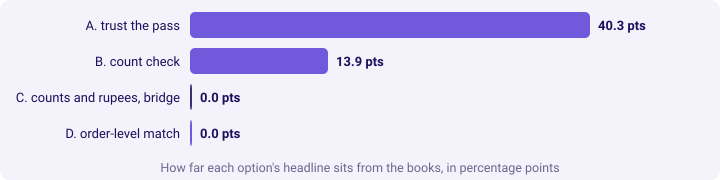

In [3]:
def quarter_totals(src, text_to_zero):
    out = {}
    for q in QUARTERS:
        s = n = 0
        for r in src:
            if r["quarter"] != q:
                continue
            v = r["amount"]
            s += (int(v) if v.isdigit() else 0) if text_to_zero else int(v.replace(",", ""))
            n += 1
        out[q] = (s, n)
    return out


def first_of_each(src):
    kept = {}
    for r in src:
        kept.setdefault(r["order_id"], r)
    return list(kept.values())


truth = change(ctl("Q1")[0], ctl("Q2")[0])
sizing = []
for name, minutes, cells, dedupe, text_fixed in [
        ("A. trust the pass", 0, 0, False, False),
        ("B. count check", 2, 1, True, False),
        ("C. counts and rupees, bridge", 15, 3, True, True),
        ("D. order-level match", 120, 6, True, True)]:
    start = time.perf_counter()
    src = first_of_each(rows) if dedupe else rows
    t = quarter_totals(src, text_to_zero=not text_fixed)
    ms = 1000 * (time.perf_counter() - start)
    reported = change(t["Q1"][0], t["Q2"][0])
    sizing.append((name, minutes, cells, len(rows), f"{ms:.2f}", f"{reported:+.1f}%", abs(reported - truth)))
kit.table(["option", "analyst minutes", "cells", "rows touched", "compute ms", "Q1 to Q2 it reports", "points off"],
          [s[:6] + (f"{s[6]:.1f}",) for s in sizing],
          caption="Four ways to check, sized on the lab export; the books say " + f"{truth:+.1f}%")
kit.bars([(s[0], round(s[6], 1)) for s in sizing], lit=(2,), fmt=lambda v: f"{v:.1f} pts",
         title="How far each option's headline sits from the books, in percentage points")

In [4]:
kit.check("the computer's cost is under a second for every option", all(float(s[4]) < 1000 for s in sizing))
kit.check("only options C and D land on the books", [round(s[6], 1) for s in sizing][2:] == [0.0, 0.0]
          and all(s[6] > 1 for s in sizing[:2]))

**The best-fit call.** C. It costs about fifteen minutes of an analyst's two hours, needs only the
control file that came with the export, and lands on the books to the rupee; the computer's share
of the cost is under a millisecond for all four, so the choice is about minutes of thought, never
about compute. B is the option most people who did check stopped at, and it still leaves the
headline about 14 points off. D names every order that differs, which C cannot, and costs a request
to Finance and most of the afternoon.

**What would change the call.** No control total at all: then C has nothing to land on, and D, or a
second export pulled from the source system for the same quarters, becomes the check. A bridge
that does not close: then C has told you there is a gap it cannot explain, and D is how you find it.

## 1. The headline the hurried run sent

Most notes this morning were built on a pass that kept the rows as they arrived and set any value
that would not convert to zero. It runs without an error.

**Predict before you run.** What Q1 to Q2 change does that pass report?

- a) A fall of a little under a third, the same as Finance's books.
- b) A rise of about a tenth.
- c) A fall of about a seventh.
- d) No change, since both quarters hold about a hundred orders.

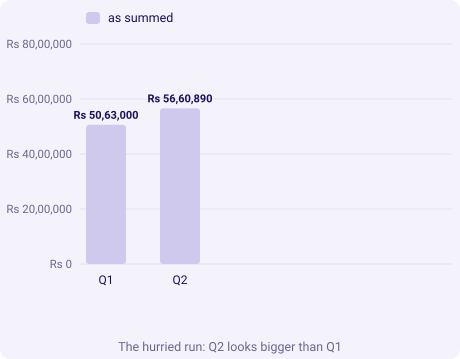

In [5]:
hurried = quarter_totals(rows, text_to_zero=True)
h_change = change(hurried["Q1"][0], hurried["Q2"][0])
kit.stats([(kit.rupees(hurried["Q1"][0]), "Q1 as summed", f"{hurried['Q1'][1]} rows"),
           (kit.rupees(hurried["Q2"][0]), "Q2 as summed", f"{hurried['Q2'][1]} rows"),
           (f"{h_change:+.1f}%", "Q1 to Q2", "the line the note led with")])
kit.columns(list(QUARTERS), [("as summed", [hurried[q][0] for q in QUARTERS])], width=460,
            fmt=lambda v: kit.rupees(v), title="The hurried run: Q2 looks bigger than Q1")

**What happened.** The answer is b. The pass reports Q2 up 11.8 percent.

**The plausible wrong answer.** "Q2 grew 11.8 percent; no action needed on the top line." The
arithmetic is right, the file is Finance's own export, and nothing on the screen looks broken.

**Why it is wrong.** Nobody asked whether the data summed is the data Finance booked. Sent to Meera,
the line tells her the quarter that fell was a good one, and the review spends its time on
Marketing's plans instead of on the fall. The check is one comparison with the control file.

In [6]:
kit.table(["quarter", "orders as summed", "Finance's orders", "rupees as summed", "Finance's rupees"],
          [(q, hurried[q][1], ctl(q)[1], kit.rupees(hurried[q][0]), kit.rupees(ctl(q)[0])) for q in QUARTERS],
          caption="The hurried run against the control totals")
kit.check("the hurried run misses Finance in both quarters, in rupees",
          all(hurried[q][0] != ctl(q)[0] for q in QUARTERS))
kit.check("the hurried run points the opposite way to the books", h_change > 0 > truth,
          f"{h_change:+.1f}% against {truth:+.1f}%")

quarter,orders as summed,Finance's orders,rupees as summed,Finance's rupees
Q1,98,98,"Rs 50,63,000","Rs 60,48,000"
Q2,109,99,"Rs 56,60,890","Rs 43,25,480"


## 2. The count check catches half of it

Option B compares orders with Finance's order counts and keeps one row per order id, the identity
rule from Wednesday.

**Predict before you run.** After B's fix, what does the headline say?

- a) Q2 up 11.8 percent, unchanged.
- b) Q2 down 28.5 percent, the books.
- c) Q2 down 14.6 percent.
- d) The check cannot run without the order-level ledger.

In [7]:
once = first_of_each(rows)
counted = quarter_totals(once, text_to_zero=True)
c_change = change(counted["Q1"][0], counted["Q2"][0])
kit.table(["quarter", "orders kept", "Finance's orders", "rupees kept", "Finance's rupees"],
          [(q, counted[q][1], ctl(q)[1], kit.rupees(counted[q][0]), kit.rupees(ctl(q)[0])) for q in QUARTERS],
          caption=f"After the count check: {len(rows)} rows read, {len(once)} kept, {len(rows) - len(once)} rejected")
kit.check("input equals kept plus rejected", len(rows) == len(once) + (len(rows) - len(once)))
kit.check("the order counts now land on Finance's in both quarters",
          all(counted[q][1] == ctl(q)[1] for q in QUARTERS))
kit.check("Q1's rupees still miss the control total", counted["Q1"][0] != ctl("Q1")[0],
          kit.rupees(ctl("Q1")[0] - counted["Q1"][0]) + " short")

quarter,orders kept,Finance's orders,rupees kept,Finance's rupees
Q1,98,98,"Rs 50,63,000","Rs 60,48,000"
Q2,99,99,"Rs 43,25,480","Rs 43,25,480"


**What happened.** The answer is c. Every order count lands, and the headline moves from +11.8 to
-14.6 percent: the right direction and half the size. A count check proves the rows are there; it
says nothing about whether each row's value survived the conversion. That is chapter 2's trap, and
it is the one a pass that "looks clean" leaves behind.

## 3. Counts and rupees, and the bridge between them

Option C adds the rupee comparison and draws the walk from what the hurried run summed to what
Finance booked, one move per decision in the log.

**Predict before you run.** Which move in the bridge is the larger?

- a) The rows the control total does not contain.
- b) The value that would not convert.
- c) They are equal.
- d) Neither; the bridge closes with no moves.

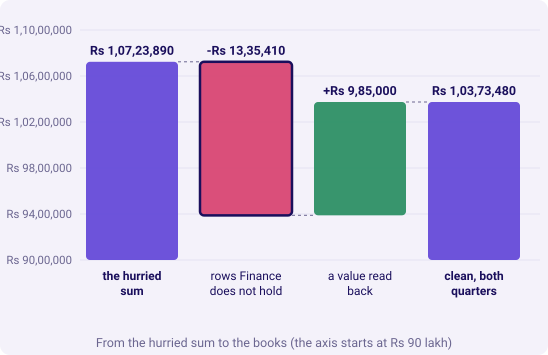

In [8]:
clean = quarter_totals(once, text_to_zero=False)
as_read = sum(hurried[q][0] for q in QUARTERS)
extra_rows = sum(counted[q][0] for q in QUARTERS) - as_read
text_back = sum(clean[q][0] for q in QUARTERS) - sum(counted[q][0] for q in QUARTERS)
kit.bridge(("the hurried sum", as_read), [("rows Finance does not hold", extra_rows),
                                          ("a value read back", text_back)],
           end_label="clean, both quarters", lit=[0], lo=9_000_000,
           title="From the hurried sum to the books (the axis starts at Rs 90 lakh)")
kit.check("the bridge lands on Finance's two quarters together",
          as_read + extra_rows + text_back == ctl("Q1")[0] + ctl("Q2")[0],
          kit.rupees(ctl("Q1")[0] + ctl("Q2")[0]))
kit.check("both quarters land, orders and rupees",
          all(clean[q] == ctl(q) for q in QUARTERS))

**What happened.** The answer is a. The rows Finance does not hold carry more rupees than the value
read back, and both moves had to be found before the bridge closed.

**The fix, and what it changes.** With both quarters on the books, the headline is a fall of 28.5
percent, from Rs 60,48,000 to Rs 43,25,480. The note changes sign, so the decision changes with it:
Monday's review now has a fall of Rs 17,22,520 to explain, and chapter 3 finds where it sits.

run,Q1,Q2,Q1 to Q2
the hurried run,"Rs 50,63,000","Rs 56,60,890",+11.8%
count check only,"Rs 50,63,000","Rs 43,25,480",-14.6%
counts and rupees,"Rs 60,48,000","Rs 43,25,480",-28.5%


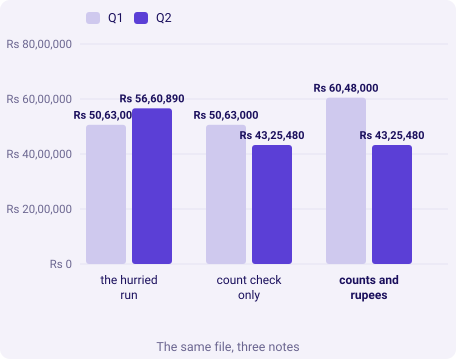

In [9]:
variants = [("the hurried run", hurried), ("count check only", counted), ("counts and rupees", clean)]
kit.table(["run", "Q1", "Q2", "Q1 to Q2"],
          [(n, kit.rupees(t["Q1"][0]), kit.rupees(t["Q2"][0]), f"{change(t['Q1'][0], t['Q2'][0]):+.1f}%")
           for n, t in variants], caption="One export, three headlines")
kit.columns([n for n, _ in variants], [("Q1", [t["Q1"][0] for _, t in variants]),
                                       ("Q2", [t["Q2"][0] for _, t in variants])],
            fmt=lambda v: kit.rupees(v), lit=(2,), title="The same file, three notes")

**Your turn.** The bridge says how many rupees Finance does not hold. It does not say which rows
they are, and Anand will ask. Type these lines into the empty cell below and run it:

```python
seen, extra = set(), []
for r in rows:
    if r["order_id"] in seen:
        extra.append(r)
    seen.add(r["order_id"])
kit.table(list(rows[0]), [list(r.values()) for r in extra], caption="Rows Finance does not hold")
```

Read the dates and the segments: what do the rows have in common, and what would you tell the
person who owns the export?

## A second route: from Finance's side back to the export

The bridge walked from the export to the books. The same answer should come from the other end:
start at each control total, add back what the log removed, subtract what it read back, and land
on what the hurried run summed. If the two routes disagree, one of the decisions in the log is
wrong.

quarter,Finance,plus rows removed,less value read back,lands on,the hurried sum
Q1,"Rs 60,48,000",Rs 0,"Rs 9,85,000","Rs 50,63,000","Rs 50,63,000"
Q2,"Rs 43,25,480","Rs 13,35,410",Rs 0,"Rs 56,60,890","Rs 56,60,890"


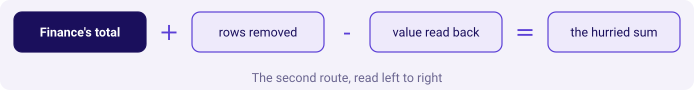

In [10]:
back = {}
for q in QUARTERS:
    removed = sum(int(r["amount"].replace(",", "")) for r in rows if r["quarter"] == q) - clean[q][0]
    read_back = clean[q][0] - counted[q][0]
    back[q] = ctl(q)[0] + removed - read_back
kit.table(["quarter", "Finance", "plus rows removed", "less value read back", "lands on", "the hurried sum"],
          [(q, kit.rupees(ctl(q)[0]), kit.rupees(back[q] - ctl(q)[0] + (clean[q][0] - counted[q][0])),
            kit.rupees(clean[q][0] - counted[q][0]), kit.rupees(back[q]), kit.rupees(hurried[q][0]))
           for q in QUARTERS], caption="The walk from the books back to the export")
kit.equation(["Finance's total", "+", "rows removed", "-", "value read back", "=", "the hurried sum"],
             title="The second route, read left to right")
kit.check("the walk back lands on the hurried sum in both quarters", all(back[q] == hurried[q][0] for q in QUARTERS))
kit.check("both routes give the same headline", round(change(ctl("Q1")[0], ctl("Q2")[0]), 1) == round(truth, 1))

**When to switch routes.** The forward bridge is the one to show Finance, because it starts from
their export. The walk back is the one to run when a bridge closes suspiciously neatly: two
mistakes that cancel pass one route and fail the other.

> **Kavya's review.** A number that has not been reconciled is not a rougher version of the right
> number. This morning it pointed the other way. Put the two checks in a cell before you compute
> the first number you plan to send, so the clock cannot remove them.

### In the interview

**[S] Walk me through how you clean and check a dataset you have never seen.** "I profile every
field first: present, convertible and distinct counts, and each count that is not what the field
should hold is a finding. I clean with a log, one row per decision with its reason, and I keep what
I reject. Then I reconcile before I analyse: rows read equal rows kept plus rows rejected, and each
period's value lands on a total from outside the file, Finance's if there is one. On a lab export
last week the count check alone moved my headline from +11.8 to -14.6 percent, and only the rupee
check got it to the books' -28.5, so I never stop at counts."

**[F] You have two hours and a raw export; what do you do first, and what do you skip?** "Profile
first, twenty minutes. I never skip the reconciliation, because it is the step that can flip the
sign of the finding and it costs fifteen minutes. I skip anything that does not change today's
answer: a second chart, a test on every segment, polishing. If there is no control total I say so
in the caveat and ask for one before the number leaves the room."

**The design question: which check, and what would make you switch?** "Counts and rupees against a
control total with a bridge, because it catches both kinds of error for fifteen minutes and needs
only what comes with the export. I switch to an order-level match against the ledger when the bridge
will not close or when there is no control total, and I say it will cost the afternoon."

### Depth: the same rows also move a branch

Rows Finance does not hold do not only inflate a total. If they sit in one segment, they
manufacture a rise in orders per customer where nothing changed. Run the tree on the hurried rows
and on the clean ones for the segment with the most consumer orders and compare the frequency branch.

In [11]:
def tree(src, q, seg):
    rs = [r for r in src if r["quarter"] == q and r["segment"] == seg and r["amount"].isdigit()]
    cust = len({r["customer_id"] for r in rs})
    rev = sum(int(r["amount"]) for r in rs)
    return len(rs), cust, len(rs) / cust, rev / len(rs), rev


seg = "Retail-Core"
h1, h2 = tree(rows, "Q1", seg), tree(rows, "Q2", seg)
c1, c2 = tree(once, "Q1", seg), tree(once, "Q2", seg)
kit.table(["Retail-Core", "orders per customer, Q1 to Q2", "revenue per order, Q1 to Q2", "revenue"],
          [("hurried rows", f"{h1[2]:.2f} to {h2[2]:.2f} ({change(h1[2], h2[2]):+.1f}%)",
            f"{kit.rupees(h1[3])} to {kit.rupees(h2[3])}", f"{change(h1[4], h2[4]):+.1f}%"),
           ("one row per order", f"{c1[2]:.2f} to {c2[2]:.2f} ({change(c1[2], c2[2]):+.1f}%)",
            f"{kit.rupees(c1[3])} to {kit.rupees(c2[3])}", f"{change(c1[4], c2[4]):+.1f}%")],
          caption="The frequency rise on the hurried rows is the rows, not the customers")
kit.check("on the hurried rows frequency rises and revenue looks flat",
          change(h1[2], h2[2]) > 15 and abs(change(h1[4], h2[4])) < 1)

Retail-Core,"orders per customer, Q1 to Q2","revenue per order, Q1 to Q2",revenue
hurried rows,1.47 to 1.77 (+20.5%),"Rs 2,050 to Rs 1,702",+0.0%
one row per order,1.47 to 1.47 (+0.0%),"Rs 2,050 to Rs 1,700",-17.1%


The hurried rows turn a basket problem into a flat segment with loyal customers. Chapter 3 reads the
clean tree properly.

**Depth: when there is no control total.** Three stand-ins, in the order a careful analyst tries
them: the same quarters in a second export pulled from the source system on another day; the
payment gateway's settlement totals for the quarter, which count collected rather than booked
money and so need their own bridge; last quarter's audited figure for the quarter that overlaps.
Each is weaker than Finance's number, and the note says which one was used.

In [12]:
kit.check_summary()